# Quantity Resolution — Visualizations

**The problem:** `4 tbsp Beef` and `4 tbsp Mint Leaves` are wildly different gram weights.

**Pipeline (`quantities.ipynb`):**
1. Parse each quantity string into a `(amount, unit)` pair: `"933g"` → `(933, 'g')`, `"4 tbsp"` → `(4, 'tbsp')`.
2. Look up grams-per-unit for each `(ingredient, unit)` pair in the **USDA SR Legacy** database:
   - Filter to portions that match the needed unit (tablespoon / teaspoon / cup / medium / clove…)
   - Prefer plain/raw descriptions; take median of up to 5 best matches → **Tier: sr_legacy**
3. If USDA has no matching entry, fall back to a **flat generic value** (e.g. 1 tbsp = 15 g) → **Tier: generic**
4. `grams = amount × g_per_unit`; combine with CO₂e (kg/kg) → `co2e_kg`.

These charts expose what came from USDA vs the fallback, which units dominated, and where the generic approximations live.

In [1]:

import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

os.makedirs('figures', exist_ok=True)
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})

# Three tiers:
#   exact_mass  — qty_unit is 'g' or 'kg'; value is already in grams, no approximation
#   sr_legacy   — USDA SR Legacy scientific portion lookup
#   generic     — flat approximation (tbsp→15 g, medium→100 g, to_taste→5 g, …)
TIER_COLORS = {
    'sr_legacy':  '#2E86AB',
    'exact_mass': '#27AE60',
    'generic':    '#F18F01',
}
TIER_LABELS = {
    'sr_legacy':  'USDA SR Legacy',
    'exact_mass': 'Exact mass (g / kg)',
    'generic':    'Generic fallback',
}

grounded = pd.read_csv('../recipe_ingredients_grounded.csv')
grounded['ingredient_lower'] = grounded['ingredient_name'].str.lower().str.strip()
grounded['tier3'] = np.where(grounded['qty_unit'].isin(['g', 'kg']), 'exact_mass', grounded['usda_tier'])

print(f"Rows   : {len(grounded):,}")
print(f"Recipes: {grounded['recipe_id'].nunique()}")
print(f"Unique ingredients : {grounded['ingredient_lower'].nunique()}")
print(f"\nTier distribution (3-tier):")
print(grounded['tier3'].value_counts().to_string())
print(f"\nUnit distribution:")
print(grounded['qty_unit'].value_counts().to_string())


Rows   : 103,908
Recipes: 9997
Unique ingredients : 58

Tier distribution (3-tier):
tier3
sr_legacy     54981
generic       31030
exact_mass    17897

Unit distribution:
qty_unit
tbsp            32016
count_medium    17948
g               17897
to_taste         9997
clove            9997
ml               8067
tsp              7986


## 1 · USDA Tier Breakdown (Overall)

What share of all recipe-ingredient rows used an actual USDA SR Legacy measurement vs the flat generic fallback?

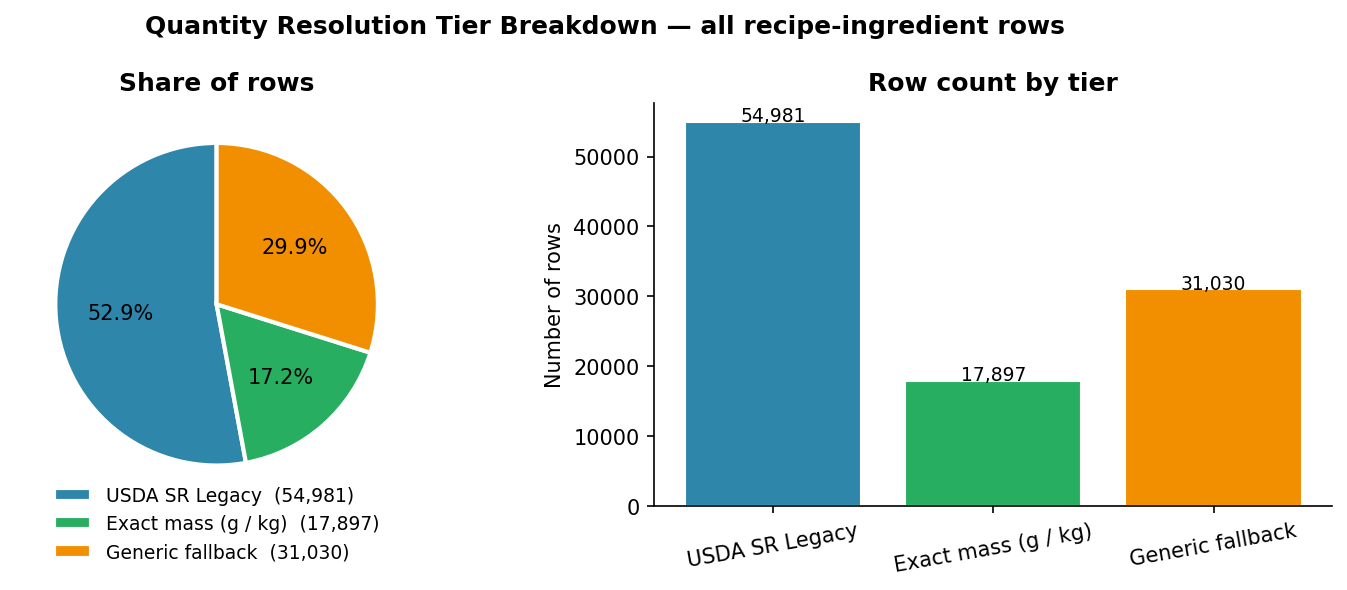

In [2]:

tier_counts = grounded['tier3'].value_counts().reindex(['sr_legacy', 'exact_mass', 'generic']).dropna()
labels = [TIER_LABELS[t] for t in tier_counts.index]
colors = [TIER_COLORS[t] for t in tier_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

wedges, _, autotexts = axes[0].pie(
    tier_counts.values, labels=None, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
)
axes[0].legend(wedges, [f"{l}  ({v:,})" for l, v in zip(labels, tier_counts.values)],
               loc='lower center', bbox_to_anchor=(0.5, -0.18), fontsize=9, frameon=False)
axes[0].set_title('Share of rows', fontweight='bold')

axes[1].bar(labels, tier_counts.values, color=colors, edgecolor='white')
for i, v in enumerate(tier_counts.values):
    axes[1].text(i, v + 50, f"{v:,}", ha='center', fontsize=9)
axes[1].set_ylabel('Number of rows')
axes[1].set_title('Row count by tier', fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].tick_params(axis='x', rotation=10)

fig.suptitle('Quantity Resolution Tier Breakdown — all recipe-ingredient rows', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/q01_usda_tier_overall.png', bbox_inches='tight')
plt.show()


## 3 · USDA Tier by Unit Type

For each unit type, what fraction of rows used USDA SR Legacy vs the generic fallback?  
Units that are exact masses (`g`, `kg`) are always generic (passthrough — no USDA lookup needed). Volume measures (`tbsp`, `tsp`, `cup`) and counts (`medium`, `clove`) may or may not hit USDA.

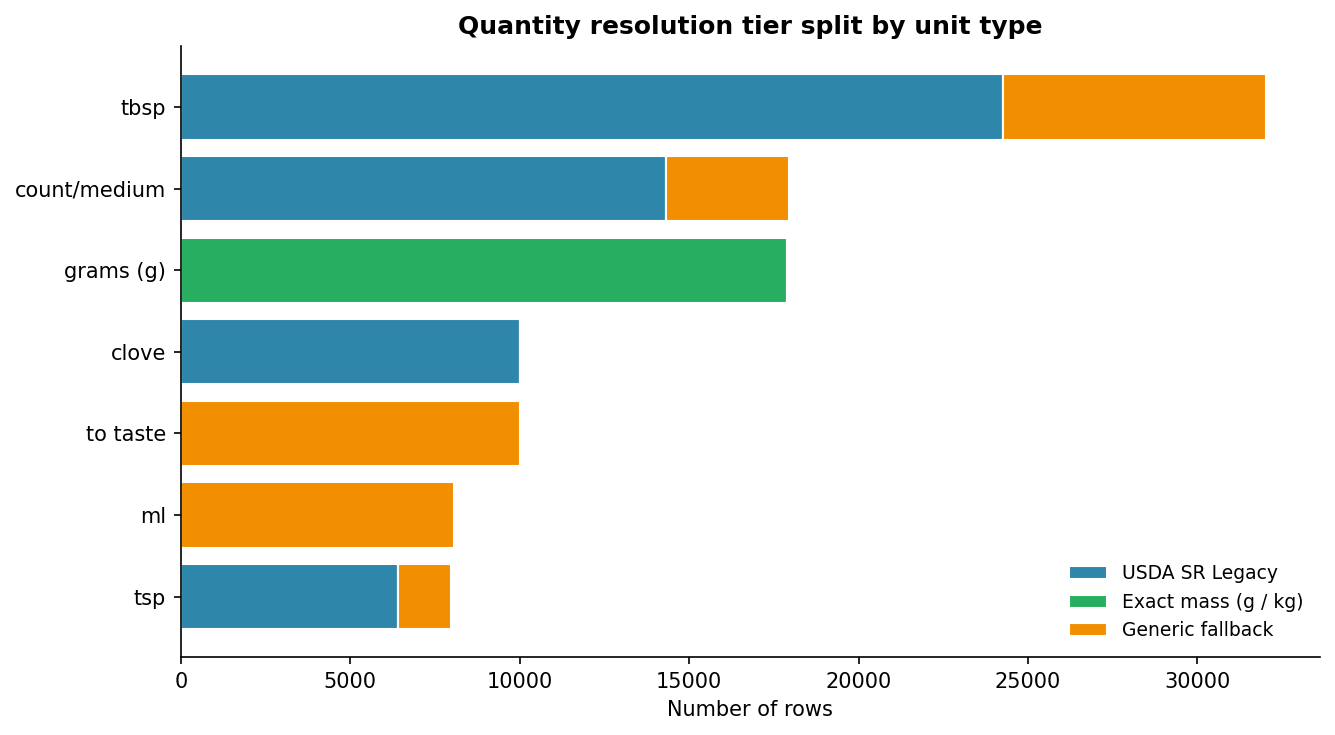

In [3]:
UNIT_LABELS = {
    'tbsp':'tbsp','tsp':'tsp','g':'grams (g)','kg':'kg',
    'ml':'ml','cup':'cup','clove':'clove','count_medium':'count/medium',
    'medium':'medium','large':'large','small':'small',
    'to_taste':'to taste','egg':'egg','fillet':'fillet','other':'other',
}

tier_unit = grounded.groupby(['qty_unit', 'tier3']).size().unstack(fill_value=0).reset_index()
tier_unit['total'] = tier_unit.reindex(columns=['sr_legacy','exact_mass','generic'], fill_value=0).sum(axis=1)
tier_unit['label'] = tier_unit['qty_unit'].map(UNIT_LABELS).fillna(tier_unit['qty_unit'])
tier_unit = tier_unit.sort_values('total', ascending=True)

tiers_present = [t for t in ['sr_legacy', 'exact_mass', 'generic'] if t in tier_unit.columns]

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(tier_unit))
for t in tiers_present:
    vals = tier_unit[t].values
    ax.barh(tier_unit['label'], vals, left=bottom,
            color=TIER_COLORS[t], label=TIER_LABELS[t], edgecolor='white')
    bottom += vals

ax.set_xlabel('Number of rows')
ax.set_title('Quantity resolution tier split by unit type', fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/q03_tier_by_unit.png', bbox_inches='tight')
plt.show()
